In [3]:
import pandas as pd 
import os

# Define the dataset path based on your exact file location
dataset_path = r"C:\Users\Allen\Documents\Activity 7\spotify_top_1000_tracks.csv"

# Load dataset
try:
    df = pd.read_csv(dataset_path, encoding="utf-8")
    # Convert release_date and extract year
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce') 
    df['year'] = df['release_date'].dt.year
    print("⬛ Dataset loaded and basic preprocessing complete!")
    print(df.head(3))
except FileNotFoundError:
    print("Error: Please make sure the CSV file is in the 'Activity 7' folder.")

Error: Please make sure the CSV file is in the 'Activity 7' folder.


In [7]:
# Updated path to look in the current folder
dataset_path = "spotify_top_1000_tracks.csv"

In [9]:
encoding="ISO-8859-1"

In [11]:
import os
print(os.getcwd())

c:\Users\SeanCyruz\Lab7_Data_Visualization_PIDO\.venv


In [13]:
# Just add the 'r' here
dataset_path = r"C:\Users\SeanCyruz\Lab7_Data_Visualization_PIDO\spotify_top_1000_tracks.csv"

In [14]:
dataset_path = "C:/Users/SeanCyruz/Lab7_Data_Visualization_PIDO/spotify_top_1000_tracks.csv"

In [18]:
import pandas as pd
import os

# 1. Use the relative path you just set up
dataset_path = r"C:\Users\SeanCyruz\Lab7_Data_Visualization_PIDO\spotify_top_1000_tracks.csv"

# 2. Load the dataset with the corrected encoding
# We use ISO-8859-1 to handle special characters in song/artist names
df = pd.read_csv(dataset_path, encoding="ISO-8859-1")

# 3. Basic Preprocessing
# Convert release_date to datetime and extract the year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce') 
df['year'] = df['release_date'].dt.year

print("⬛ Dataset loaded and basic preprocessing complete!")
# This shows you the first 3 rows to confirm everything looks right
print(df.head(3))

⬛ Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                 SeÃ±orita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                          SeÃ±orita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [19]:
import numpy as np

# Clean up text columns by removing extra spaces
df['track_name'] = df['track_name'].str.strip() 
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()

# Convert 'year' to integer (filling missing values with 0 first)
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']
df = df.drop(columns=cols_to_drop, errors='ignore') 

# Feature Engineering: Create Tempo Category based on BPM
tempo_bins = [0, 100, 140, np.inf] 
tempo_labels = ['Slow', 'Medium', 'Fast']

if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)
    print("Feature 'tempo_category' created.") 
else:
    print("Warning: 'tempo' column not found; skipping 'tempo_category'.")

# Remove duplicate songs by the same artist
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')

print(f"⬛ Data cleaning complete. Final Row Count: {len(df)}")

⬛ Data cleaning complete. Final Row Count: 971


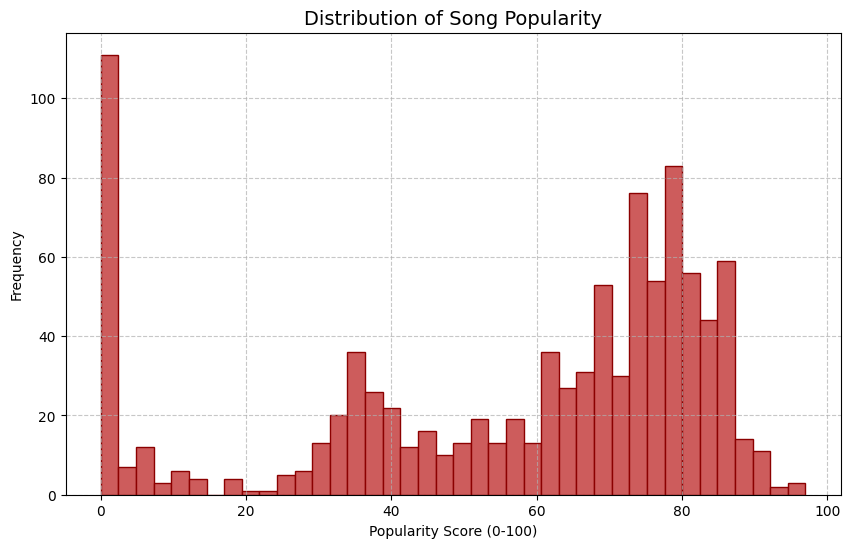

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 
plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')

plt.title('Distribution of Song Popularity', fontsize=14) 
plt.xlabel('Popularity Score (0-100)') 
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7) 

plt.show()

C:\Users\SeanCyruz\AppData\Local\Temp\ipykernel_22776\3795486392.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='viridis')


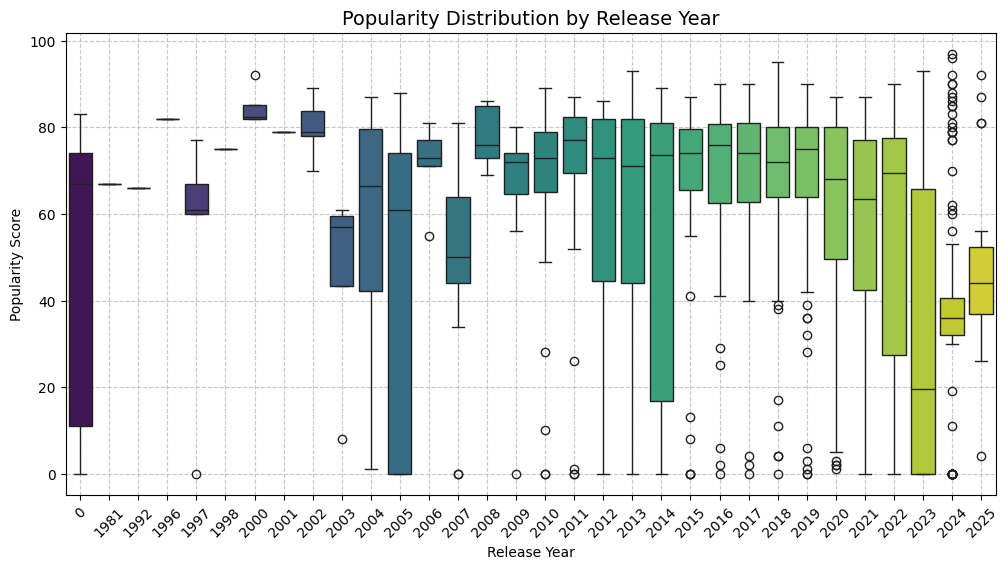

In [21]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='viridis') 

plt.title('Popularity Distribution by Release Year', fontsize=14) 
plt.xlabel('Release Year')
plt.ylabel('Popularity Score') 
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7) 

plt.show()

In [23]:
student_name = "Pido" 
student_id = "255526" # 
id_num = int(student_id[-3:])

# Automatic color generation as per lab instructions
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

print(f"Colors generated: {color1} and {color2}")

Colors generated: #622a46 and #1c7e38


C:\Users\SeanCyruz\AppData\Local\Temp\ipykernel_22776\1487137879.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')


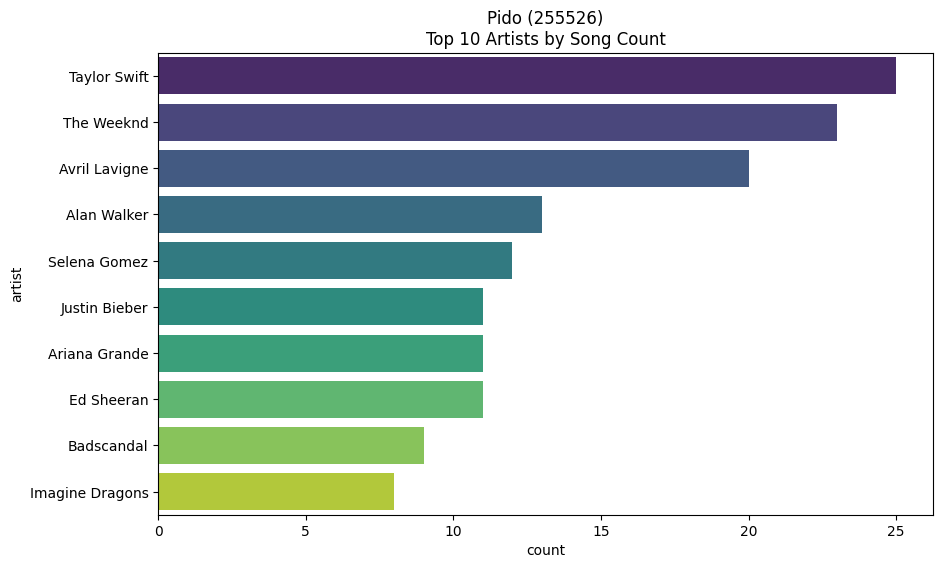

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

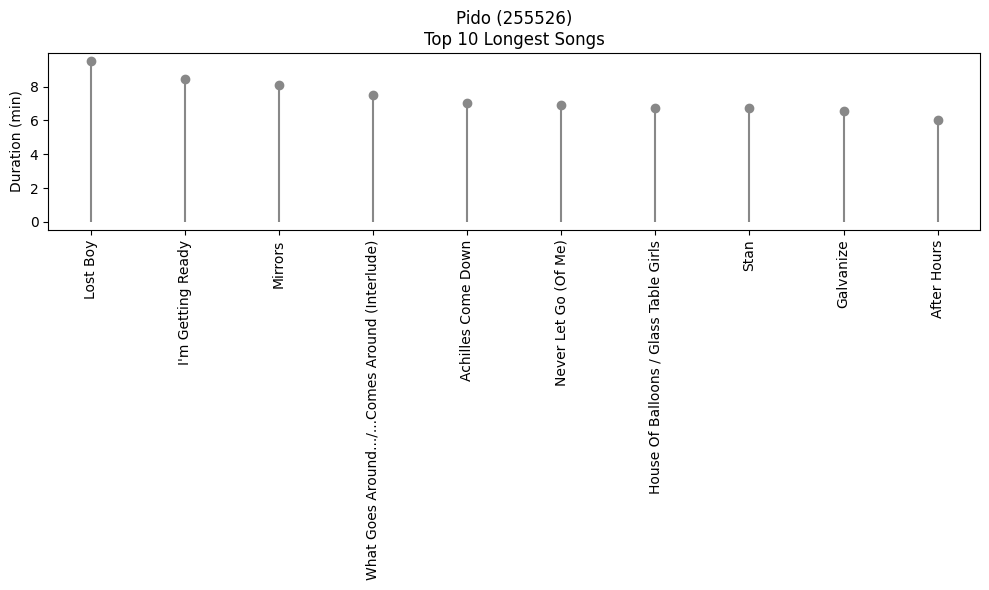

In [25]:
longest = df.nlargest(10, 'duration_min')
plt.figure(figsize=(10, 6))
plt.stem(longest['track_name'], longest['duration_min'], linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

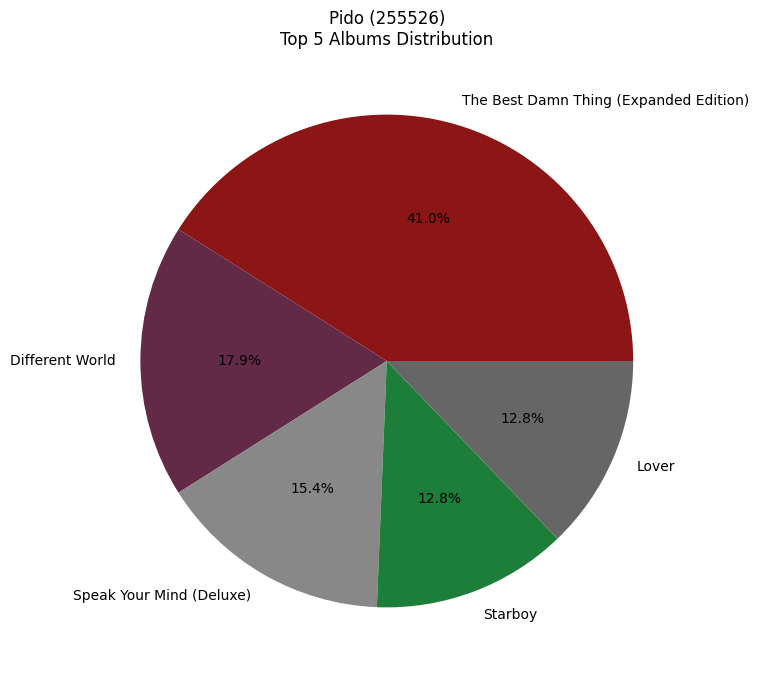

In [26]:
top_albums = df['album'].value_counts().head(5)
colors_pie = ['#8C1515', color1, '#888888', color2, '#666666']
plt.figure(figsize=(8, 8))
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors_pie)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Sean Cyruz" # Replace with your actual name
student_id = "202512345"    # Replace with your actual ID
id_num = int(student_id[-3:])

# Lab-mandated color generation logic
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

# Prepare the decade column used in several plots
df['decade'] = (df['year'] // 10) * 10

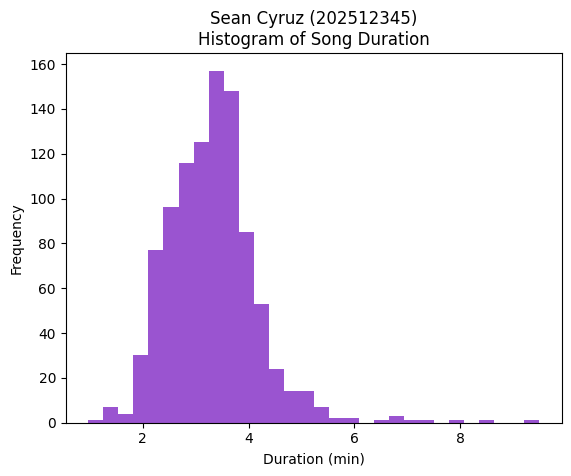

In [28]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

C:\Users\SeanCyruz\AppData\Local\Temp\ipykernel_22776\3049450671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


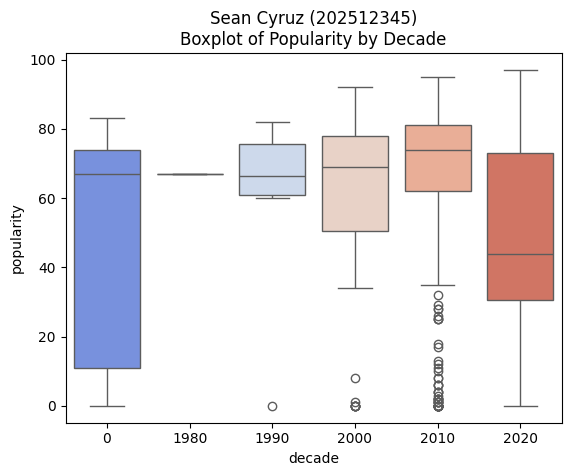

In [29]:
# Create the decade column first
df['decade'] = (df['year'] // 10) * 10 
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

C:\Users\SeanCyruz\AppData\Local\Temp\ipykernel_22776\2261941100.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')


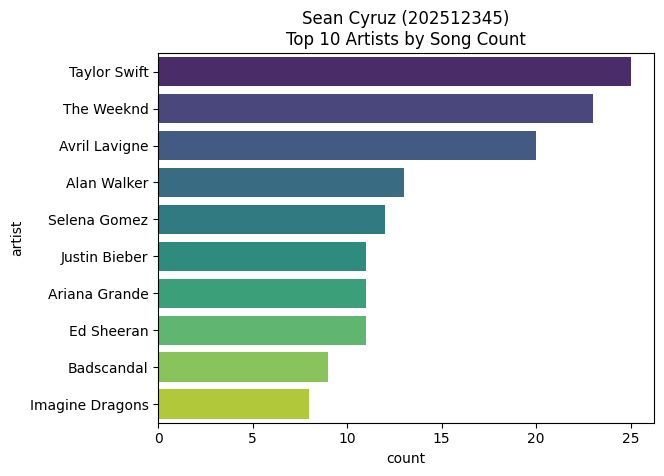

In [32]:
sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

C:\Users\SeanCyruz\AppData\Local\Temp\ipykernel_22776\2228049048.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', orient='h')


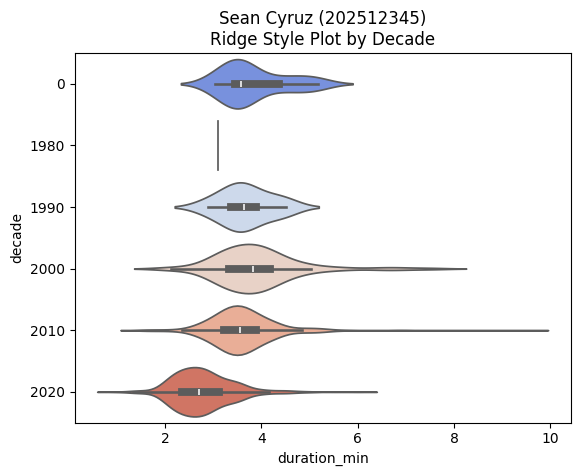

In [33]:
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', orient='h')
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.show()

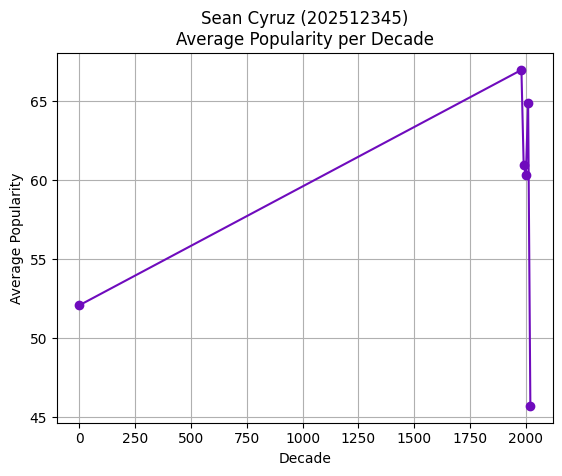

In [34]:
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

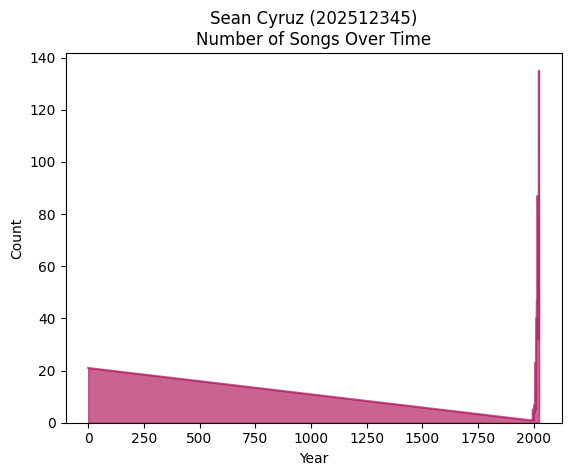

In [35]:
count_by_year = df['year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

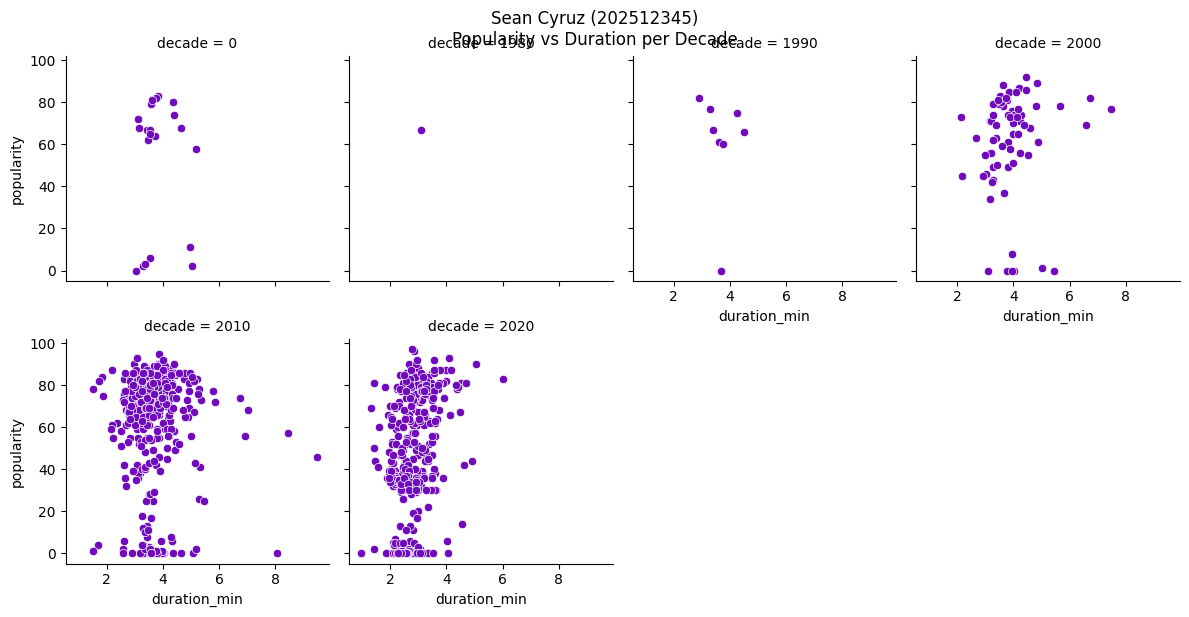

In [36]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)
plt.show()

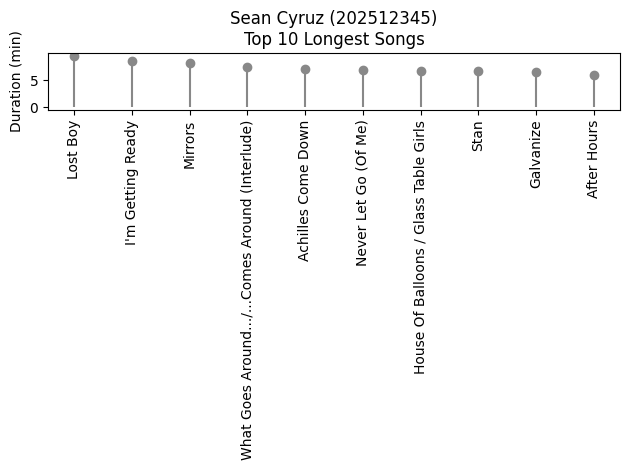

In [37]:
longest = df.nlargest(10, 'duration_min')
plt.stem(longest['track_name'], longest['duration_min'], linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

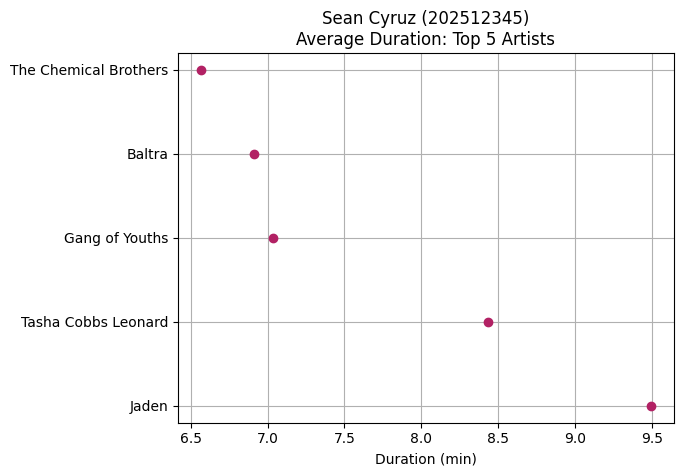

In [38]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)
plt.show()

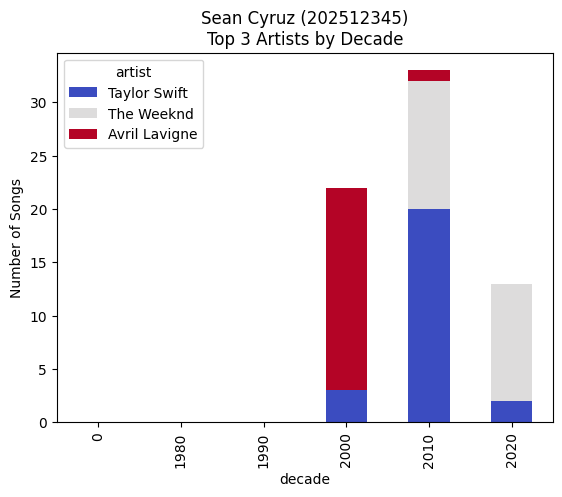

In [39]:
crosstab = pd.crosstab(df['decade'], df['artist'])
top3 = df['artist'].value_counts().head(3).index
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()

C:\Users\SeanCyruz\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SeanCyruz\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


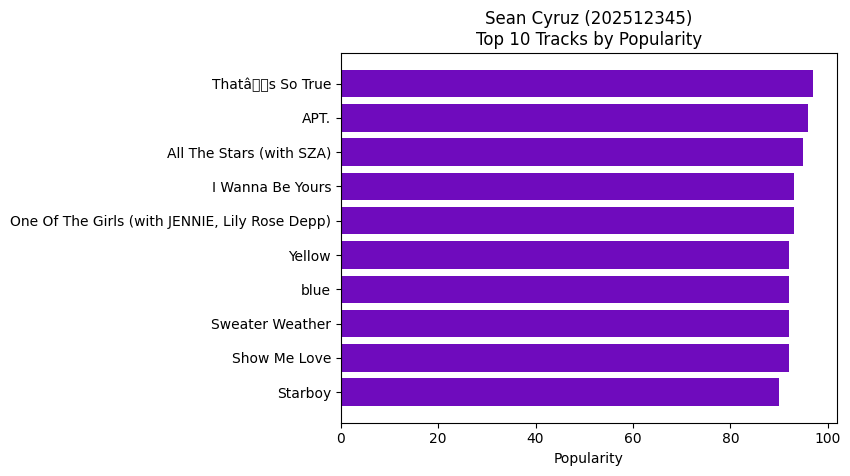

In [40]:
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()

C:\Users\SeanCyruz\AppData\Local\Temp\ipykernel_22776\4060842567.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])
C:\Users\SeanCyruz\AppData\Local\Temp\ipykernel_22776\4060842567.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])


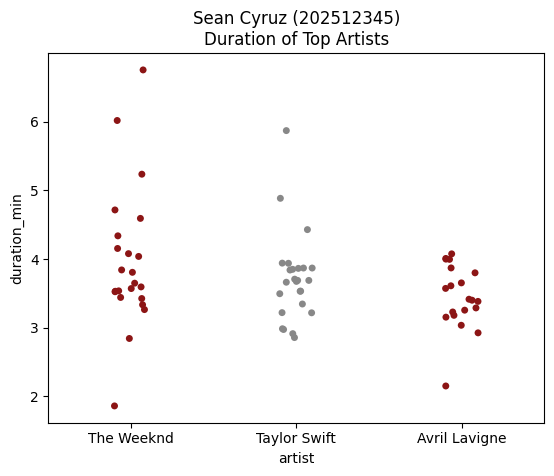

In [41]:
top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()

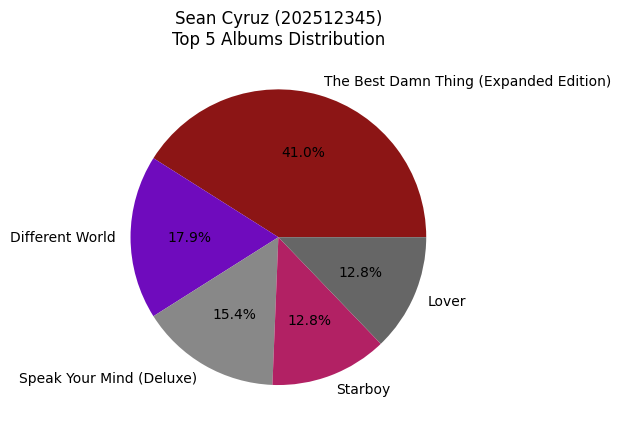

In [42]:
top_albums = df['album'].value_counts().head(5)
colors = ['#8C1515', color1, '#888888', color2, '#666666']
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors)
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

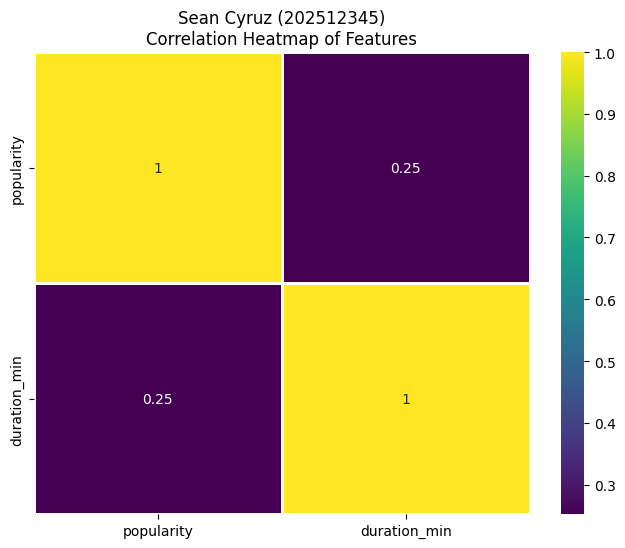

In [45]:
# Using heatmap instead of clustermap to avoid the RuntimeError
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='viridis', linewidths=.75)

plt.title(f"{student_name} ({student_id})\nCorrelation Heatmap of Features")
plt.show()

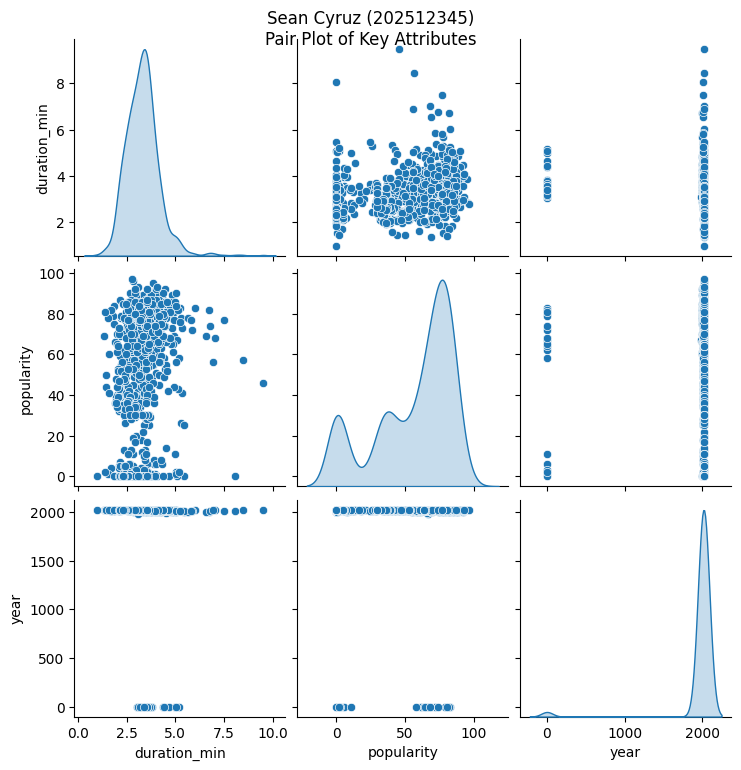

In [46]:
sns.pairplot(df[['duration_min', 'popularity', 'year']], diag_kind='kde')
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02)
plt.show()

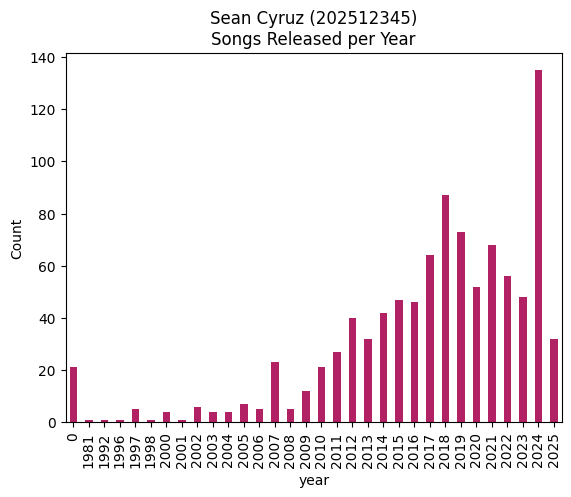

In [47]:
df['year'].value_counts().sort_index().plot(kind='bar', color=color2)
plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.show()

C:\Users\SeanCyruz\AppData\Local\Temp\ipykernel_22776\1671609876.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


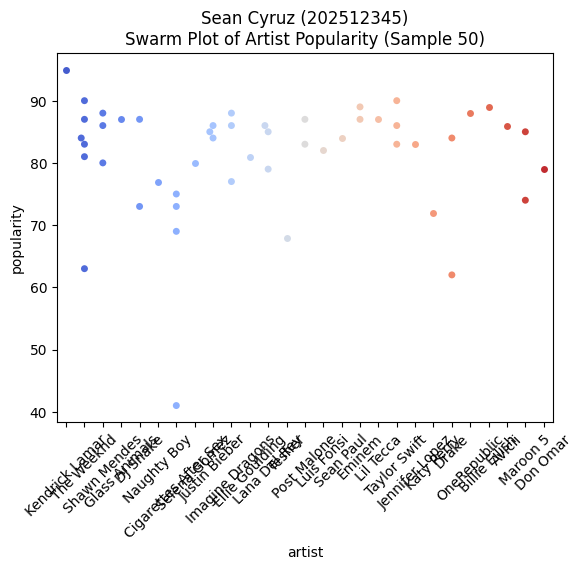

In [48]:
sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45)
plt.show()

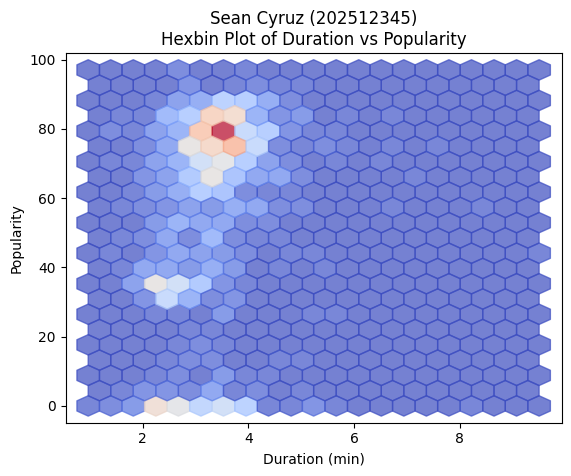

In [49]:
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7)
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
plt.show()

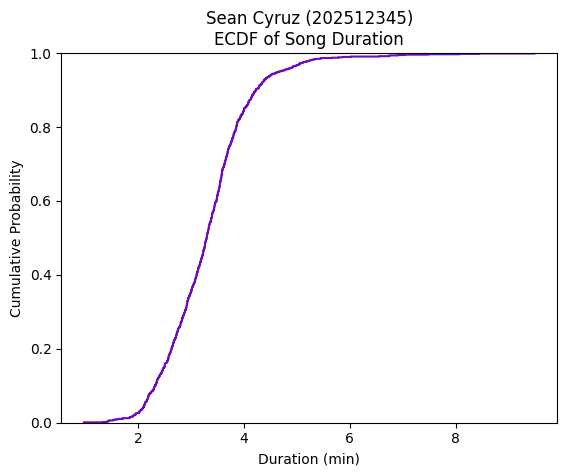

In [50]:
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()

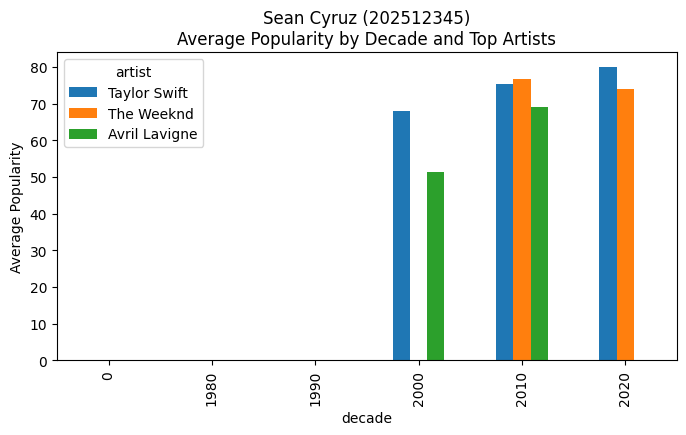

In [51]:
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)
top3 = df['artist'].value_counts().head(3).index
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.show()